# MITGCM Temporal Potential Energy  Analysis 

**Purpose**: Code for computing the eddy and mean potential energy along the CalCOF transect.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import gsw
from geopy.distance import geodesic
from scipy.ndimage import uniform_filter1d
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from filtering import lanczos_lowpass_filter, butter_lowpass_filter
from plotScaleAnalysis import add_freq_marker

Set data analysis parameters

In [65]:
# Set processing parameters
option_energy        = 'FPE'     # Specifies which component of the kinetic energy will be computed
option_filter        = 'boxcar'  # Specifies which filtering approach to take. Options include 'butter', 'Lanczos'

# Set time and space parameters  
T_cut        = 90                            # Spcifies the cutoff for filtering. Units: days
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_mld = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
filename_vel = PATH + "mitgcm_intermediate_data_vel_hrly_transect_profiles.nc"
nc_tsd = Dataset(filename_tsd, 'r')
nc_vel = Dataset(filename_vel, 'r')

# Extract data variables
depth     = nc_tsd.variables['depth'][:]
depth_mid = nc_tsd.variables['depth_mid'][:]
lon       = nc_tsd.variables['LON'][:]
lat       = nc_tsd.variables['LAT'][:]
dist      = nc_tsd.variables['DIST'][:]     
time      =  num2date(nc_tsd.variables['time'][:], nc_tsd.variables['time'].units)

sig = nc_tsd.variables['SIG'][:]
Nz  = nc_tsd.variables['NZ'][:]
u_along_shore = nc_vel.variables['v_cross'][:]
u_cross_shore = nc_vel.variables['u_along'][:]
u_along_shore_bar = nc_vel.variables['v_cross_bar'][:]
u_cross_shore_bar = nc_vel.variables['u_along_bar'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon = lon[::-1]
lat = lat[::-1]
sig = sig[::-1,:,:]
Nz = Nz[::-1,:]
u_along_shore = u_along_shore[::-1,:,:]
u_cross_shore = u_cross_shore[::-1,:,:]
u_along_shore_bar = u_along_shore_bar[::-1,:]
u_cross_shore_bar = u_cross_shore_bar[::-1,:]

#-------------------------------------------------------#
# Mixed Layer depth Data
#-------------------------------------------------------#
filename_mld  = PATH_mld + "/mitgcm_transect_mld_climatology.npz"

# Load data 
ds_mld   = np.load(filename_mld, allow_pickle=True)

# Extract data variables
mld                  = ds_mld['mld']                 # Units: meters
mld_monthly_mean     = ds_mld['mld_monthly_mean']    # Units: meters
mld_monthly_var      = ds_mld['mld_monthly_var']     # Units: meters
mld_monthly_stdm     = ds_mld['mld_monthly_stdm'] 
mld_monthly_stdv     = ds_mld['mld_monthly_stdv'] 
lat_mld              = ds_mld['lat'] 
lon_mld              = ds_mld['lon'] 
time_mld             = ds_mld['time']
time_mld_monthly     = ds_mld['time_monthly']

Compute cumulative distance along line 80.0 for the mixed layer depth 

In [5]:
# Initialize array 
dist_mld = np.zeros(len(lon_mld))

# Loop through stations 
for i in range(1,len(lon_mld)): 

    # Define i and i + 1 points along transect
    pt1 = (lat_mld[i-1], lon_mld[i-1])
    pt2 = (lat_mld[i],   lon_mld[i])

    # Compute distance in kilometers along transect
    dist_mld[i] = dist_mld[i-1] + geodesic(pt1, pt2).km

# Find the indices specified by lat and lon bounds
dist_mask = ((lat_mld >= lat_bnds[0]) & (lat_mld <= lat_bnds[1]) & (lon_mld >= lon_bnds[0]) & (lon_mld <= lon_bnds[1]))
idx_dist_mld  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat_mld   = lat_mld[idx_dist_mld]
lon_mld   = lon_mld[idx_dist_mld]
dist_mld  = dist_mld[idx_dist_mld]

Load in the ocean bottom land mask

In [6]:
filename = PATH + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Set the locations of each cce mooring

In [7]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

### Section 1: Compute Available Potential Energy without filtering

Compute reference potential density $\rho_0$ and the mean potential density profile as a function of depth and distance from shore $\hat\rho(r,z)$

In [11]:
# Compute the reference potential density rho_0
rho_0 = np.ma.mean(sig) + 1000                       # Convert potential density anomaly to potential density by adding 1000 kg/m^3

# Compute the mean potential density profile by averaging over time at each depth and distance point
sig_mean = np.ma.mean(sig, axis=0)

# Compute the perturbation potential density by subtracting the mean profile from the instantaneous potential density at each time step
sig_prime = sig - sig_mean[np.newaxis, :, :]

Compute the perturbation bouyancy 

In [12]:
# Set gravitational acceleration
g = 9.81 # Units: m/s^2

# Compute the buoyancy perturbation b' using the formula b' = - (sig' / rho_0) * g
b_prime = -1 * (sig_prime / rho_0) * g 

Compute available potential energy (APE) as a function of time and distance along the CalCOFI line 80

In [56]:
# Linearly interpolate b_prime to depth_mid by averaging adjacent depth levels
b_prime_mid = 0.5*(b_prime[:, :, :-1] + b_prime[:, :, 1:])  

# Expand dimensions of Nz to match the shape of b_prime_mid for element-wise division
Nz_expanded = np.expand_dims(Nz, axis=1)  # shape (184,1,89)

# Compute the integrand for the APE calculation 
integrand = 0.5 * rho_0 * (b_prime_mid**2) / (Nz_expanded**2)

# Set depth to positive values for integration
depth_mid_positive = np.abs(depth_mid)

# Compute the APE by integrating the integrand over depth for each time step 
APE = np.trapezoid(integrand, depth_mid_positive, axis=2)

Compute the time mean and variance of the APE 

In [57]:
# Compute mean, variance, and standard deviation of APE across time at each distance point
APE_mean = np.ma.mean(APE, axis=1)
APE_var = np.ma.var(APE, ddof=1, axis=1)
APE_std = np.ma.std(APE, ddof=1, axis=1)

# Compute Standard error of the mean (SEM) for APE
APE_stdm = APE_std/np.sqrt(len(time)*(1/200))

# Compute the standard error of the variance for APE 
APE_stdv = APE_var * np.sqrt(2/(len(time)*(1/200)-1))

Slice the data so that the analysis only considers offshore distances up to 123 degrees west

In [58]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat_n          = lat[idx_dist]
lon_n          = lon[idx_dist]
dist_n         = dist[idx_dist]

APE_mean       = APE_mean[idx_dist]
APE_var        = APE_var[idx_dist]
APE_std        = APE_std[idx_dist]
APE_stdm       = APE_stdm[idx_dist]
APE_stdv       = APE_stdv[idx_dist]

Plot the mean and variance of the Available Potential Energy 

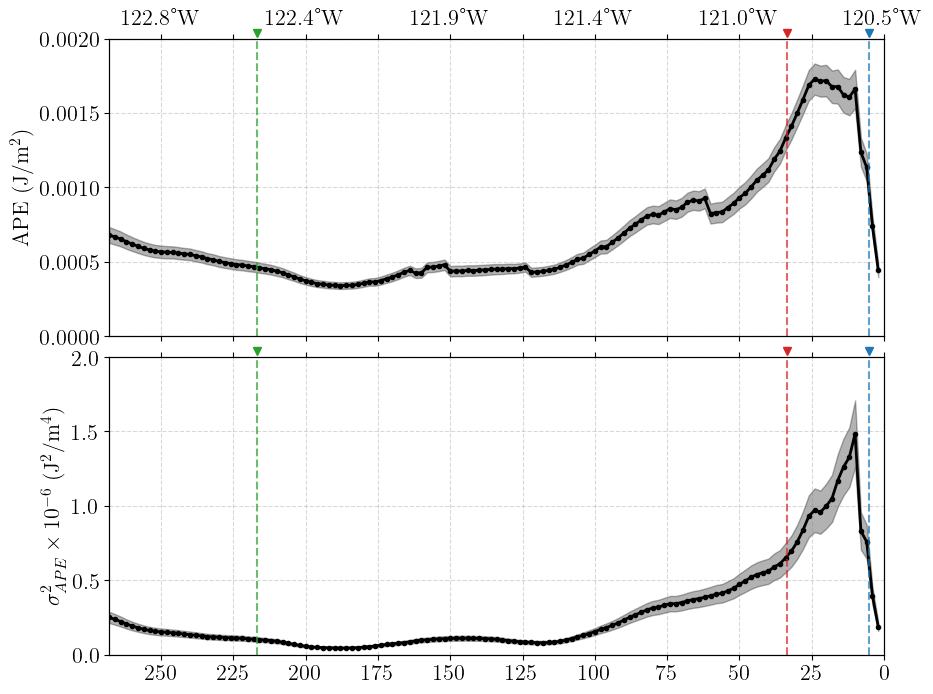

python(89161) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89162) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89164) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89166) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89167) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(89169) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [63]:
# Set plotting parameters 
cmap = cmo.thermal
label_mean = r'APE (J/m$^2$)'
label_var  = r'$\sigma_{APE}^2 \times 10^{-6}$ (J$^2$/m$^4$)'

# Create figure
fig, axes = plt.subplots(2,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot time-mean of APE
ax.plot(dist_n, APE_mean, '.-', color = 'k', lw=2)

# Plot the standard error of the mean 
ax.fill_between(dist_n, APE_mean - APE_stdm, APE_mean + APE_stdm, color='k', alpha=0.3)

# Set axis attributes
ax.set_ylabel(label_mean)
ax.set_xlim(0,dist_n[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_ylim(0,0.002)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_n + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_n, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_n[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Plot time-mean of APE
ax.plot(dist_n, APE_var*10**6, '.-', color = 'k', lw=2)

# Plot the standard error of the variance 
ax.fill_between(dist_n, APE_var*10**6 - APE_stdv*10**6, APE_var*10**6 + APE_stdv*10**6, color='k', alpha=0.3)

# Set axis attributes
ax.set_ylabel(label_var)
ax.set_xlim(0,dist_n[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_ylim(0,2)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_n + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_n, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_n[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'figS30.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


### Section 1: Compute Available Potential Energy with filtering

In [64]:
# Compute low-pass filtered potential density (with respect to time)
if option_filter == 'boxcar': 

    # Set parameters
    dt_hours = (time_dt[1] - time_dt[0]).total_seconds() / 3600  # time step in hours
    window_size = int(T_cut * 24 / dt_hours)                     # number of timesteps in 90 days

    # Filter data 
    sig_L = uniform_filter1d(sig_prime, size=window_size, axis=1, mode='nearest')

elif option_filter == 'Lanczos':

    # Set parameters
    dt = 1.0            # 1 day sampling
    cutoff = 1.0/T_cut  # cutoff frequency in cycles/day
    window = 60         # ~2*T is typical

    # Filter data 
    sig_L = lanczos_lowpass_filter(sig_prime, cutoff=cutoff, window=window, dt=dt, axis=1)

elif option_filter == 'butter': 

    # Set parameters
    dt = 1.0        # 1 day sampling
    cutoff = 1.0/T_cut # cycles per day

    # Filter data
    sig_L = butter_lowpass_filter(sig_prime, cutoff=cutoff, dt=dt, order=4, axis=1)

# Compute high-pass filtered velocities 
sig_H = sig_prime - sig_L

# Set gravitational acceleration
g = 9.81 # Units: m/s^2

# Expand dimensions of Nz to match the shape of b_prime_mid for element-wise division
Nz_expanded = np.expand_dims(Nz, axis=1) 

# Set depth to positive values for integration
depth_mid_positive = np.abs(depth_mid)

Compute components of potential energy 

In [ ]:
# Compute components of the kinetic energy 
if option_energy == 'MPE': 

    # Compute the buoyancy perturbation for low pass
    b_prime_L = -1 * (sig_L / rho_0) * g 

    # Linearly interpolate b_prime to depth_mid by averaging adjacent depth levels
    b_prime_mid_L = 0.5*(b_prime_L[:, :, :-1] + b_prime_L[:, :, 1:])  

    # Compute the integrand for the MPE calculation 
    integrand = 0.5 * rho_0 * (b_prime_mid_L**2) / (Nz_expanded**2)

    # Compute the MPE 
    MPE = np.trapezoid(integrand, depth_mid_positive, axis=2)

    # Compute time-mean field 
    MPE_mean = np.ma.mean(MPE, axis=1) 
    MPE_std = np.ma.std(MPE, axis=1, ddof=1)
    MPE_var = np.ma.var(MPE, axis=1, ddof=1)

    # Compute the standard error of the mean and variance for the depth-averaged mean and variance FKE 
    MPE_stdm = np.sqrt(MPE_std/len(time)*(1/200))
    MPE_stdv = MPE_var * np.sqrt(2/(len(time)*(1/200) - 1))

elif option_energy == 'EPE': 

    # Compute the buoyancy perturbation for high pass
    b_prime_H = -1 * (sig_H / rho_0) * g 

    # Linearly interpolate b_prime to depth_mid by averaging adjacent depth levels
    b_prime_mid_H = 0.5*(b_prime_H[:, :, :-1] + b_prime_H[:, :, 1:])  

    # Compute the integrand for the EPE calculation 
    integrand = 0.5 * rho_0 * (b_prime_mid_H**2) / (Nz_expanded**2)

    # Compute the EPE 
    EPE = np.trapezoid(integrand, depth_mid_positive, axis=2)

    # Compute time-mean field 
    EPE_mean = np.ma.mean(EPE, axis=1) 
    EPE_std = np.ma.std(EPE, axis=1, ddof=1)
    EPE_var = np.ma.var(EPE, axis=1, ddof=1)

    # Compute the standard error of the mean and variance for the depth-averaged mean and variance FKE 
    EPE_stdm = np.sqrt(EPE_std/len(time)*(1/200))
    EPE_stdv = EPE_var * np.sqrt(2/(len(time)*(1/200) - 1))

elif option_energy == 'FPE': 

    # Compute the buoyancy perturbation for high and low pass
    b_prime_H = -1 * (sig_H / rho_0) * g 
    b_prime_L = -1 * (sig_L / rho_0) * g 

    # Linearly interpolate b_prime to depth_mid by averaging adjacent depth levels
    b_prime_mid_H = 0.5*(b_prime_H[:, :, :-1] + b_prime_H[:, :, 1:])  
    b_prime_mid_L = 0.5*(b_prime_L[:, :, :-1] + b_prime_L[:, :, 1:])  

    # Compute the integrand for the EPE calculation 
    integrand_H = 0.5 * rho_0 * (b_prime_mid_H**2) / (Nz_expanded**2)
    integrand_L = 0.5 * rho_0 * (b_prime_mid_L**2) / (Nz_expanded**2)

    # Compute the EPE and MPE
    EPE = np.trapezoid(integrand_H, depth_mid_positive, axis=2)
    MPE = np.trapezoid(integrand_L, depth_mid_positive, axis=2)

    # Compute the fraction of the total Available potential energy associated with Eddy potential energy
    FPE = EPE/(EPE + MPE)

    # Compute time-mean field 
    FPE_mean = np.ma.mean(FPE, axis=1) 
    FPE_std = np.ma.std(FPE, axis=1, ddof=1)
    FPE_var = np.ma.var(FPE, axis=1, ddof=1)

    # Compute the standard error of the mean and variance for the depth-averaged mean and variance FKE 
    FPE_stdm = np.sqrt(FPE_std/len(time)*(1/200))
    FPE_stdv = FPE_var * np.sqrt(2/(len(time)*(1/200) - 1))

Set plotting parameters

In [67]:
# Set plotting parameters 
cmap = cmo.thermal

if option_energy == 'MPE': 
    data_mean = MPE_mean
    data_var  = MPE_var
    data_stdm = MPE_stdm
    data_stdv = MPE_stdv
    label_mean = r'MPE (J/m$^2$)'
    label_var  = r'$\sigma_{MPE}^2$ (J$^2$/m$^4$)'
    levels_mean = np.logspace(np.log10(1e-3), np.log10(2e-2), num=35) #np.arange(0,0.03 + 0.001,0.001)  
    levels_var  = np.logspace(np.log10(1e-6), np.log10(1e-3), num=35) #np.arange(0,2,0.05)
    norm_mean = mcolors.LogNorm(vmin=1e-3, vmax=2e-2)
    norm_var = mcolors.LogNorm(vmin=1e-6, vmax=1e-3)
elif option_energy == 'EPE':
    data_mean = EPE_mean
    data_var  = EPE_var
    data_stdm = EPE_stdm
    data_stdv = EPE_stdv
    label_mean = r'EKE (m$^2$/s$^2$)'
    label_var  = r'$\sigma_{EKE}^2$ (m$^2$/s$^2$)'
    levels_mean = np.logspace(np.log10(3e-3), np.log10(1e-1), num=35)  #np.arange(0,0.03 + 0.001,0.001) 
    levels_var  = np.logspace(np.log10(3e-6), np.log10(4e-2), num=35) #np.arange(0,0.0005,0.000005)
    norm_mean = mcolors.LogNorm(vmin=3e-3, vmax=1e-1)
    norm_var = mcolors.LogNorm(vmin=3e-6, vmax=4e-2)
elif option_energy == 'FPE':
    data_mean = FPE_mean
    data_var  = FPE_var
    data_stdm = FPE_stdm
    data_stdv = FPE_stdv
    label_mean = r'FPE (\%)'
    label_var  = r'$\sigma_{FPE}^2 ($\%$)$'
    levels_mean = np.arange(0.3,0.8+0.02,0.02)*100
    levels_var = np.arange(0.04,0.11+0.0025,0.0025)*100

Slice the data so that the analysis only considers offshore distances up to 123 degrees west

In [71]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
data_mean       = data_mean[idx_dist]
data_var        = data_var[idx_dist]
data_stdm       = data_stdm[idx_dist]
data_stdv       = data_stdv[idx_dist]

Plot data field

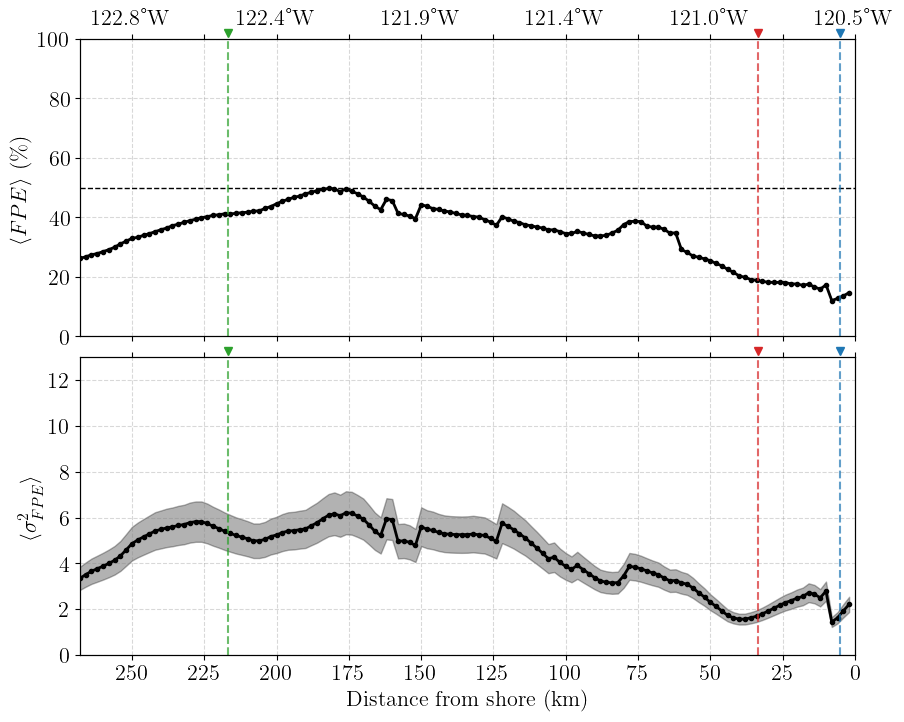

In [74]:
# Create figure
fig, axes = plt.subplots(2,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot depth integrated time-mean 
ax.plot(dist_n, data_mean*100, '.-', color = 'k', lw=2)

# Plot the 50% contour
ax.axhline(50, color='k', ls='--', lw=1)

# Plot the standard error of the mean 
ax.fill_between(dist_n, data_mean*100 - data_stdm*100, data_mean*100 + data_stdm*100, color='k', alpha=0.3)

# Set axis attributes
ax.set_ylabel(r'$\langle FPE \rangle$ ($\%$)')
ax.set_xlim(0,dist_n[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_ylim(0,100)
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_n + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_n, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_n[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Plot depth averaged time-mean 
ax.plot(dist_n, data_var*100, '.-', color = 'k', lw=2)

# Plot the standard error of the mean 
ax.fill_between(dist_n, data_var*100 - data_stdv*100, data_var*100 + data_stdv*100, color='k', alpha=0.3)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle \sigma_{FPE}^2 \rangle$')
ax.set_xlim(0,dist_n[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_ylim(0,13)
ax.set_yticks(np.arange(0,12+2,2))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_n + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_n, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_n[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'figS31.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)
